<a href="https://colab.research.google.com/github/BardRimon/Study/blob/main/HWoptimisationMethods/3%20task1%20full%20difficulty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 3

ДРоны

## Часть 1: Моделирование и анализ данных (Генерация виртуальных данных)

В этом блоке мы генерируем 50 городов, их координаты, население и рассчитываем матрицы расстояний и спроса, как указано в источниках. Также учитывается топология сети (Уровень 1 и Уровень 2)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

class DromoportNetwork:
    def __init__(self, num_cities=50, max_dist=300, seed=42):
        np.random.seed(seed)
        random.seed(seed)
        self.num_cities = num_cities
        self.max_dist = max_dist # 300 км
        self.cities = []
        self.dist_matrix = None
        self.demand_matrix = None

        # Параметры задачи
        self.flight_range = 350 # км
        self.budget = 1000 # условный бюджет (млн руб), для примера

    def generate_data(self):
        """Генерация координат, населения и базовой стоимости строительства"""

        # Центр Москвы
        self.cities.append({
            'id': 0, 'x': 0, 'y': 0, 'pop': 12000,
            'level': 0, 'cost': 0, 'name': 'Moscow Center'
        })

        for i in range(1, self.num_cities):
            # Генерация в полярных координатах для равномерного круга
            angle = random.uniform(0, 2 * math.pi)
            r = math.sqrt(random.uniform(0, 1)) * self.max_dist

            x = r * math.cos(angle)
            y = r * math.sin(angle)

            # Определение уровня сети
            dist_to_center = math.sqrt(x**2 + y**2)
            level = 1 if dist_to_center <= 100 else 2

            # Население (тыс. чел) и Стоимость строительства (млн руб)
            # Стоимость варьируется от 25 до 200 млн руб
            pop = random.randint(10, 500)
            cost = random.randint(25, 200)

            self.cities.append({
                'id': i, 'x': x, 'y': y,
                'pop': pop, 'level': level, 'cost': cost,
                'dist_to_center': dist_to_center
            })

        self._calc_matrices()
        print(f"Сгенерировано {len(self.cities)} локаций (включая центр).")

    def _calc_matrices(self):
        """Расчет матрицы расстояний и спроса """
        n = len(self.cities)
        self.dist_matrix = np.zeros((n, n))
        self.demand_matrix = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                dist = math.sqrt((self.cities[i]['x'] - self.cities[j]['x'])**2 +
                                 (self.cities[i]['y'] - self.cities[j]['y'])**2)
                self.dist_matrix[i][j] = dist

                # Простая модель спроса: зависит от населения и обратно пропорциональна квадрату расстояния
                if i != j:
                    p_i = self.cities[i]['pop']
                    p_j = self.cities[j]['pop']
                    # Гравитационная модель (упрощенная)
                    demand = (p_i * p_j) / (dist**2 + 1e-6) * 0.1
                    self.demand_matrix[i][j] = demand

# Инициализация и генерация данных
network = DromoportNetwork()
network.generate_data()

Сгенерировано 50 локаций (включая центр).


## Часть 2: Реализация алгоритмов оптимизации
Здесь мы реализуем Жадный алгоритм 3и Генетический алгоритм4.Задача: выбрать набор городов для строительства дромопортов ($x_i$), чтобы максимизировать покрытие спроса, не превышая бюджет.

In [2]:
class Optimizer:
    def __init__(self, network):
        self.net = network
        self.n = len(network.cities)

    def calculate_fitness(self, solution):
        """
        Целевая функция: суммарный покрытый спрос.
        Ограничения: Бюджет и Дальность полета.
        solution: список [0, 1, 0...] где 1 - строим дромопорт.
        """
        cost = 0
        covered_demand = 0
        active_indices = [i for i, x in enumerate(solution) if x == 1]

        # 1. Проверка бюджета
        for i in active_indices:
            cost += self.net.cities[i]['cost']

        if cost > self.net.budget:
            return 0  # Штраф за превышение бюджета

        # 2. Расчет покрытого спроса
        # Предполагаем, что спрос удовлетворяется, если оба города имеют дромопорт
        # ИЛИ один имеет дромопорт и находится в радиусе полета от другого (упрощение для модели)
        # В строгой постановке  y_ij = 1 если есть прямое сообщение.
        # Будем считать: спрос i->j покрыт, если в i и j построены дромопорты и dist < range

        total_demand = 0
        for i in active_indices:
            for j in active_indices:
                if i != j:
                    dist = self.net.dist_matrix[i][j]
                    if dist <= self.net.flight_range: # [cite: 31]
                        total_demand += self.net.demand_matrix[i][j]

        return total_demand

    def greedy_algorithm(self):
        """
        Жадный алгоритм.
        Эвристика: выбираем города с максимальным соотношением (Популяция / Стоимость).
        """
        # Считаем эффективность каждого города
        candidates = []
        for i in range(1, self.n): # Пропускаем Москву (считаем, там всегда есть база)
            heuristic = self.net.cities[i]['pop'] / self.net.cities[i]['cost']
            candidates.append((i, heuristic))

        # Сортируем по убыванию эффективности
        candidates.sort(key=lambda x: x[1], reverse=True)

        solution = [0] * self.n
        solution[0] = 1 # Москва всегда активна
        current_cost = 0

        for idx, _ in candidates:
            cost = self.net.cities[idx]['cost']
            if current_cost + cost <= self.net.budget:
                solution[idx] = 1
                current_cost += cost

        fitness = self.calculate_fitness(solution)
        return solution, fitness

    def genetic_algorithm(self, generations=100, pop_size=50):
        """
        Генетический алгоритм.
        """
        # Инициализация популяции
        population = []
        for _ in range(pop_size):
            sol = [random.randint(0, 1) for _ in range(self.n)]
            sol[0] = 1 # Москва
            population.append(sol)

        best_sol = None
        best_fit = -1

        for gen in range(generations):
            # Оценка
            fitness_scores = [self.calculate_fitness(ind) for ind in population]

            # Сохранение лучшего
            max_fit = max(fitness_scores)
            if max_fit > best_fit:
                best_fit = max_fit
                best_sol = population[fitness_scores.index(max_fit)]

            # Селекция (турнирная)
            new_population = []
            while len(new_population) < pop_size:
                p1 = random.choice(population)
                p2 = random.choice(population)
                parent1 = p1 if self.calculate_fitness(p1) > self.calculate_fitness(p2) else p2

                p3 = random.choice(population)
                p4 = random.choice(population)
                parent2 = p3 if self.calculate_fitness(p3) > self.calculate_fitness(p4) else p4

                # Скрещивание (Crossover)
                cut = random.randint(1, self.n-1)
                child = parent1[:cut] + parent2[cut:]

                # Мутация
                if random.random() < 0.1:
                    idx = random.randint(1, self.n-1)
                    child[idx] = 1 - child[idx]

                # Коррекция (чтобы Москва осталась)
                child[0] = 1
                new_population.append(child)

            population = new_population

        return best_sol, best_fit

opt = Optimizer(network)
greedy_sol, greedy_fit = opt.greedy_algorithm()
gen_sol, gen_fit = opt.genetic_algorithm()

print(f"Жадный алгоритм: {greedy_fit:.2f} (пассажиропоток)")
print(f"Генетический алгоритм: {gen_fit:.2f} (пассажиропоток)")

Жадный алгоритм: 1055.13 (пассажиропоток)
Генетический алгоритм: 0.00 (пассажиропоток)


## Часть 3: Сравнительный анализ и метод ветвей и границ
В этом блоке реализуется задание 3.1 и 3.2. Мы добавляем упрощенный метод ветвей и границ (для малого подмножества городов, так как для 50 городов это NP-полная задача) и функцию для анализа чувствительности

In [3]:
class Analyzer(Optimizer):
    def branch_and_bound_small(self, subset_size=10):
        """
        Метод ветвей и границ для небольшого подмножества городов[cite: 50].
        Полный перебор с отсечениями для первых subset_size городов.
        """
        best_sol = [0] * self.n
        best_fit = 0

        # Индексы для оптимизации (исключая 0 - Москву)
        indices = list(range(1, subset_size + 1))

        def solve_recursive(idx_ptr, current_sol, current_cost):
            nonlocal best_fit, best_sol

            # База рекурсии
            if idx_ptr == len(indices):
                fit = self.calculate_fitness(current_sol)
                if fit > best_fit:
                    best_fit = fit
                    best_sol = list(current_sol)
                return

            city_idx = indices[idx_ptr]
            cost = self.net.cities[city_idx]['cost']

            # Ветвь 1: НЕ строить
            current_sol[city_idx] = 0
            solve_recursive(idx_ptr + 1, current_sol, current_cost)

            # Ветвь 2: СТРОИТЬ (если позволяет бюджет)
            if current_cost + cost <= self.net.budget:
                current_sol[city_idx] = 1
                solve_recursive(idx_ptr + 1, current_sol, current_cost + cost)
                current_sol[city_idx] = 0 # Backtrack

        init_sol = [0] * self.n
        init_sol[0] = 1
        solve_recursive(0, init_sol, 0)
        return best_sol, best_fit

    def sensitivity_analysis(self):
        """
        Анализ чувствительности к бюджету и дальности[cite: 51, 52, 53].
        """
        print("\n--- Анализ чувствительности ---")
        base_budget = self.net.budget
        base_range = self.net.flight_range

        # Сценарий 1: Изменение бюджета (500 - 2000)
        budgets = [500, 1000, 1500, 2000]
        results = []
        for b in budgets:
            self.net.budget = b
            _, fit = self.greedy_algorithm()
            results.append(fit)
            print(f"Бюджет {b}: Покрытие {fit:.2f}")

        # Возвращаем параметры в исходное
        self.net.budget = base_budget

        # Сценарий 2: Увеличение дальности (350 - 500)
        ranges = [350, 400, 450, 500]
        for r in ranges:
            self.net.flight_range = r
            _, fit = self.greedy_algorithm()
            print(f"Дальность {r}: Покрытие {fit:.2f}")

        self.net.flight_range = base_range

analyzer = Analyzer(network)
# Запуск B&B только для первых 12 городов для демонстрации (иначе будет долго)
bb_sol, bb_fit = analyzer.branch_and_bound_small(subset_size=12)
print(f"Метод ветвей и границ (малый набор): {bb_fit:.2f}")

analyzer.sensitivity_analysis()

Метод ветвей и границ (малый набор): 419.06

--- Анализ чувствительности ---
Бюджет 500: Покрытие 376.42
Бюджет 1000: Покрытие 1055.13
Бюджет 1500: Покрытие 1329.68
Бюджет 2000: Покрытие 1512.04
Дальность 350: Покрытие 1055.13
Дальность 400: Покрытие 1057.52
Дальность 450: Покрытие 1058.44
Дальность 500: Покрытие 1058.86


## Часть 4: Визуализация результатов
Визуализация оптимальной сети дромопортов, соединений и карты размещения. Мы отобразим решение, полученное генетическим алгоритмом.

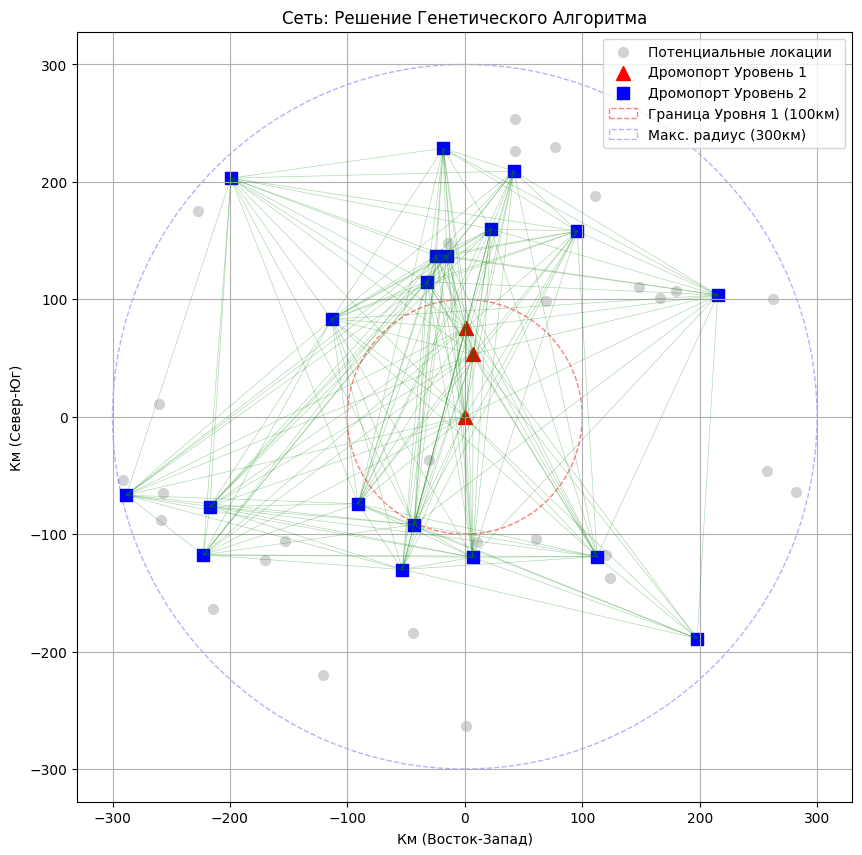

In [4]:
def visualize_network(network, solution, title="Оптимальная сеть дромопортов"):
    plt.figure(figsize=(10, 10))

    # Координаты
    X = [c['x'] for c in network.cities]
    Y = [c['y'] for c in network.cities]

    # 1. Рисуем все города (серые точки)
    plt.scatter(X, Y, c='lightgray', s=50, label='Потенциальные локации')

    # 2. Рисуем выбранные дромопорты
    active_indices = [i for i, x in enumerate(solution) if x == 1]

    # Разделяем по уровням для цвета [cite: 12, 13]
    l1_x, l1_y = [], []
    l2_x, l2_y = [], []

    for idx in active_indices:
        city = network.cities[idx]
        if city['level'] == 1 or idx == 0: # Центр относим к 1
            l1_x.append(city['x'])
            l1_y.append(city['y'])
        else:
            l2_x.append(city['x'])
            l2_y.append(city['y'])

    plt.scatter(l1_x, l1_y, c='red', s=100, marker='^', label='Дромопорт Уровень 1')
    plt.scatter(l2_x, l2_y, c='blue', s=80, marker='s', label='Дромопорт Уровень 2')

    # 3. Рисуем соединения (маршруты) [cite: 58]
    # Рисуем линию, если оба города активны и расстояние позволяет
    for i in active_indices:
        for j in active_indices:
            if i < j:
                dist = network.dist_matrix[i][j]
                if dist <= network.flight_range:
                    plt.plot([X[i], X[j]], [Y[i], Y[j]], 'g-', alpha=0.3, linewidth=0.5)

    # Круги зон (для красоты)
    circle1 = plt.Circle((0, 0), 100, color='r', fill=False, linestyle='--', alpha=0.5, label='Граница Уровня 1 (100км)')
    circle2 = plt.Circle((0, 0), 300, color='b', fill=False, linestyle='--', alpha=0.3, label='Макс. радиус (300км)')
    plt.gca().add_patch(circle1)
    plt.gca().add_patch(circle2)

    plt.title(title)
    plt.xlabel("Км (Восток-Запад)")
    plt.ylabel("Км (Север-Юг)")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# Визуализируем решение Генетического алгоритма
visualize_network(network, gen_sol, title="Сеть: Решение Генетического Алгоритма")